## In-Class Guided Exercise:

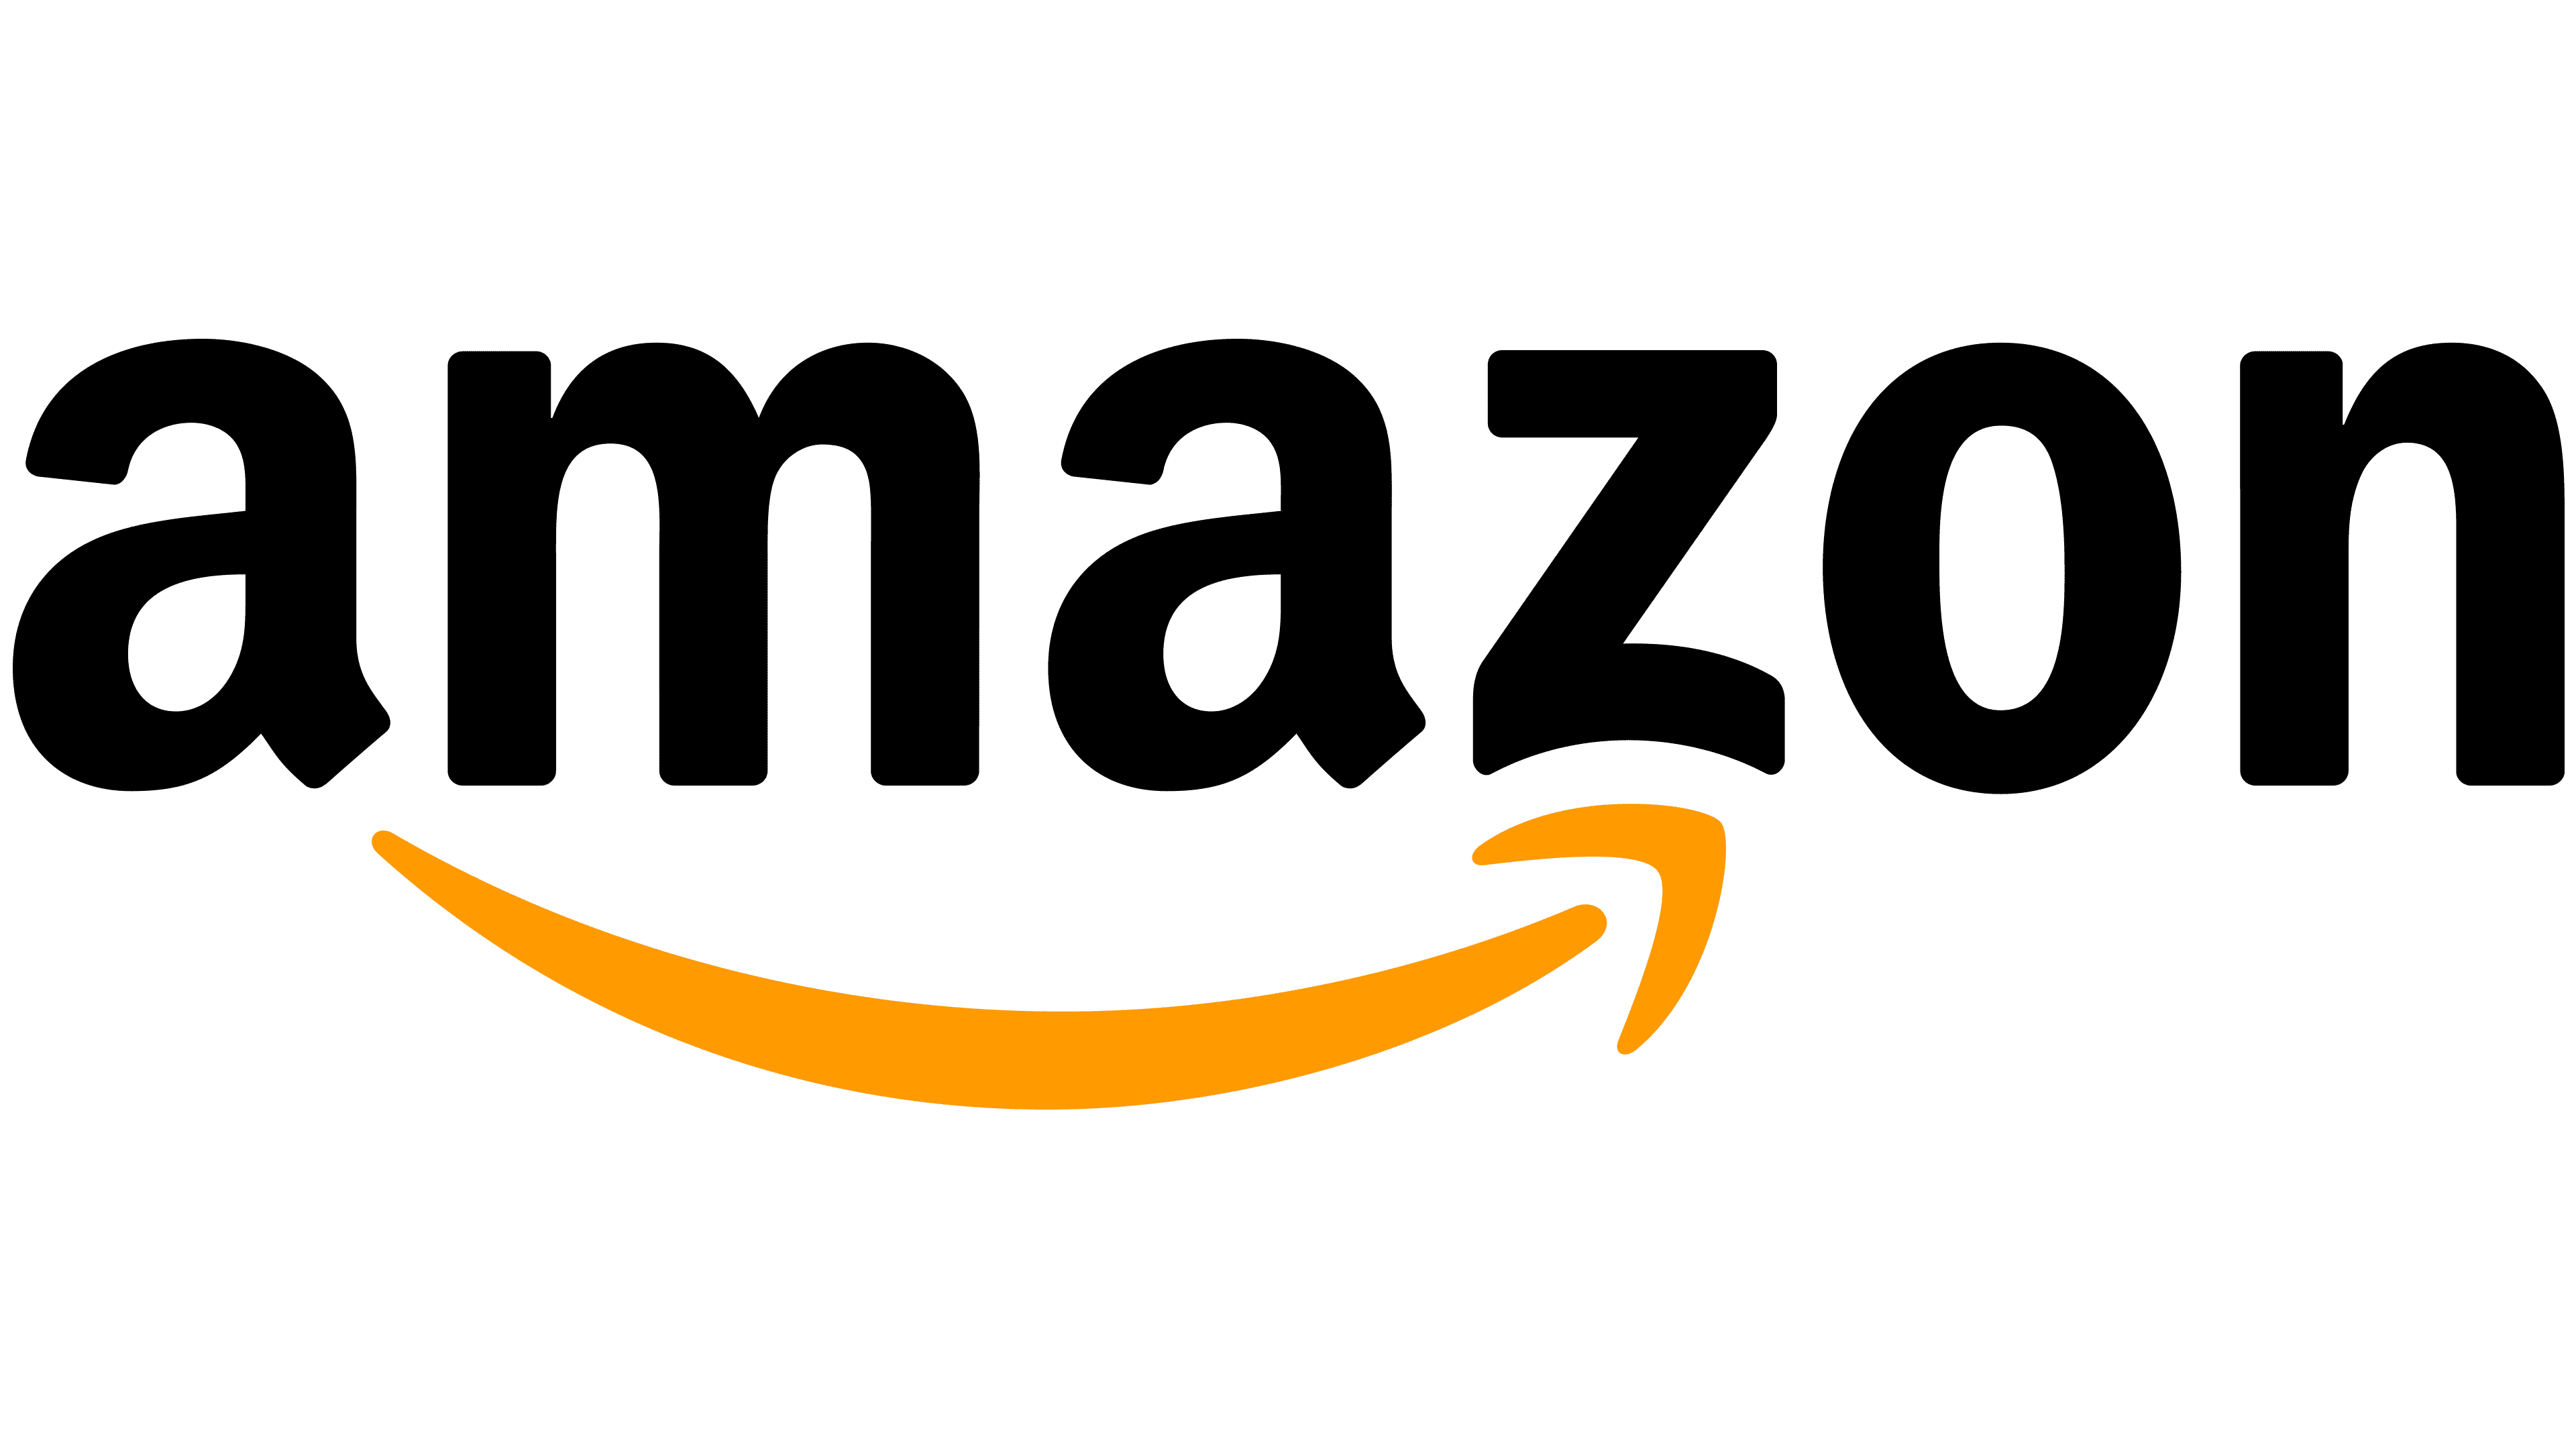



### Import needed libraries

In [22]:
import requests
import httpx  # if you want to use httpx instead of requests

import pandas as pd
from bs4 import BeautifulSoup
from time import sleep


### Steps on using BeautifulSoup:
#### 1. Use `requests` to access the url of the web page you want to scrape

In [23]:
url="https://www.amazon.sa/-/en/s?k=Computer+Tablets&i=computers&rh=n%3A16966433031&language=en&c=ts&qid=1706531941&ts_id=16966433031&ref=sr_pg_1"




In [24]:
html_page =requests.get(url)

In [25]:
# Check the status_code
html_page.status_code
# 200 mean OK 

200

In [26]:
# show the first 2000 characters of the html 

html_page.text[0:200]

'<!doctype html><html lang="en-ae" class="a-no-js" data-19ax5a9jf="dingo"><!-- sp:feature:head-start -->\n<head><script>var aPageStart = (new Date()).getTime();</script><meta charset="utf-8"/>\n<!-- sp:e'

#### 2. Now that we have the web page, we can parse it with beautifulsoup:

In [27]:
soup = BeautifulSoup(html_page.text, 'html.parser') #<shift + tab> 

- Get the title of the page using the tag 'title':

In [28]:
page_title = soup.title.string
page_title

'Tablets: Buy Now Online at Best Prices in Saudi | Souq is now Amazon.sa'

#### 3. Get all the items in that page
- Use `inspect` on the web page to know how to collect the items 
- Create a variable that contains all the items in that web page


In [53]:
# bigger box selection

amazon = soup.find_all('div', class_ = 'sg-col-4-of-4 sg-col-4-of-24 sg-col-4-of-12 s-result-item s-asin sg-col-4-of-16 sg-col s-widget-spacing-small sg-col-4-of-8 sg-col-4-of-20')

In [54]:
# Check one of the items collected
amazon[0]

<div class="sg-col-4-of-4 sg-col-4-of-24 sg-col-4-of-12 s-result-item s-asin sg-col-4-of-16 sg-col s-widget-spacing-small sg-col-4-of-8 sg-col-4-of-20" data-asin="B0FQ5XPNH7" data-component-type="s-search-result" data-index="2" data-uuid="62363071-2e5b-4f82-96fe-af24dd94a6af" id="62363071-2e5b-4f82-96fe-af24dd94a6af" role="listitem"><div class="sg-col-inner"><div cel_widget_id="MAIN-SEARCH_RESULTS-2" class="s-widget-container s-spacing-small s-widget-container-height-small celwidget slot=MAIN template=SEARCH_RESULTS widgetId=search-results_1" data-csa-c-item-id="amzn1.asin.1.B0FQ5XPNH7" data-csa-c-pos="1" data-csa-c-type="item" data-csa-op-log-render=""><span class="a-declarative" data-action="puis-card-container-declarative" data-csa-c-func-deps="aui-da-puis-card-container-declarative" data-csa-c-item-id="amzn1.asin.B0FQ5XPNH7" data-csa-c-owner="puis" data-csa-c-posx="1" data-csa-c-type="item" data-render-id="rcsrlctb7z5x21yozqyx4e3mwt" data-version-id="v2j36pgodmvsbo2tmbaj1p6v8t0"><d

In [55]:
len(amazon)

24

#### 4. Using one item, try to collect the information that you want to scrape
- In our web page here, we want to collect the following:
    - Product Title
    - Link
    - Price
    - Rating
    - Number of Reviews



##### 4.1 *Get the Product Title*

In [56]:
amazon[5].find('h2')['aria-label']

'OTEETO TAB 11 Pro Tablet/10.1 Inch IPS LCD/8GB RAM + 512 GB ROM/5G Network/6000 mAh/8MP Front + 13MP Rear Camera/Octa Core 1.3GHz/Android 13/Includes Keyboard,Touch Pen,Mouse (Blue)'

##### 4.2 *Get the Link*

In [57]:
'https://www.amazon.sa' + amazon[5].find('a')['href']

'https://www.amazon.sa/-/en/OTEETO-TAB-11-Pro-Keyboard/dp/B0CW36162D'

##### 4.3 *Get the Price*

In [58]:
amazon[5].find(class_ = 'a-offscreen').text.replace('SAR\xa0', '')

'350.75'

##### 4.4 *Get the Rating*

In [59]:
amazon[5].find(class_ = 'a-size-small a-color-base').text

'2.7'

In [60]:
# getting only the first part of the rating instead of all 
# or you can split it at a later stage

amazon[5].find(class_ = 'a-size-small a-color-base').text[0]

'2'

##### 4.5 *Get Number of Reviews*

In [61]:
# same problem you faced in the previous cell will be faced here

amazon[5].find(class_ = 'a-size-mini puis-normal-weight-text s-underline-text').text

'(83)'

#### 5. Collect all the information of all the items using `loops`
- Now, once we know how to get in information we want from one item, we can now collect all the information from all the items using `for loop`
- First of all, we need to create a list for each info we want to collect and append the scraped info to those lists

In [ ]:
product_title = []
product_price = []
reviews_num = []
link = []
rating = []
for p in range(1,6):
    url = f'https://www.amazon.sa/-/en/s?k=Computer+Tablets&i=computers&rh=n%3A16966433031&language=en&c=ts&qid=1706531941&ts_id=16966433031&ref=sr_pg_{p}'
    html_page = requests.get(url)
    soup = BeautifulSoup(html_page.text, 'html.parser')
    amazon = soup.find_all('div', class_ = 'sg-col-inner')
    
    for i in amazon:
        try:
            product_title.append(i.find('h2')['aria-label'])
        except:
            product_title.append(None)
    
        try:
            product_price.append(i.find(class_ = 'a-offscreen').text.replace('SAR\xa0', ''))
        except:
            product_price.append(None)
    
        try:
            reviews_num.append(i.find(class_ = 'a-size-mini puis-normal-weight-text s-underline-text').text)
        except:
            reviews_num.append(None)
    
        try:
            link.append('https://www.amazon.sa' + i.find('a')['href'])
        except:
            link.append(None)
    
        try:
            rating.append(i.find(class_ = 'a-size-small a-color-base').text[0])
        except:
            rating.append(None)

#### 7. Create a DataFrame to save all the scraped info. into a table.


In [51]:
# Create a DataFrame using pd.DataFrame()
amazon_df = pd.DataFrame(
    {
        'product_title' : product_title,
        'product_price' : product_price,
        'reviews_num' : reviews_num,
        'link' : link,
        'rating' : rating
    }
) 


In [52]:
amazon_df

,product_title,product_price,reviews_num,link,rating
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,640.53,(109),https://www.amazon.sa/-/en/Samsung-Galaxy-Andr...,4
...,...,...,...,...,...
145,"Xiaomi Pad 7 8+ 256GB Mi Tablet, Display 12.1 ...","1,298.00",(18),https://www.amazon.sa/-/en/Xiaomi-Tablet-Displ...,3
146,"TABWEE T60 Android 16 Tablet with Keyboard, 12...",899.99,(118),https://www.amazon.sa/-/en/TABWEE-T60-Keyboard...,4
147,"Samsung Galaxy Tab S10+, AI Tablet, Android Ta...","3,203.08",(86),https://www.amazon.sa/-/en/Samsung-Android-Ant...,4
148,Lenovo Tab One Tablet | 8.7 Inch 1340 x 800 LC...,398.48,(212),https://www.amazon.sa/-/en/Lenovo-Tab-One-Disp...,3


#### 8. Save your dataframe to a `CSV` file
- Save the output to a csv file (excluding the index)

In [41]:
# Save the output to a csv file (excluding the index)

amazon_df.to_csv("amazon.csv",index=False)